In [1]:
import pandas as pd
import numpy as np 
import os
import json

In [2]:
NUM_EXP = 5
NUM_DATA_POINTS = 10000

**load the data**

In [3]:
#read the json file
data_file_path = "../data/processed/multinli_1.0_train_cleaned.csv"
data = pd.read_csv(data_file_path, sep='µ')

#get a random sample of the data
data = data.sample(n = NUM_DATA_POINTS, random_state = 42)
data.head()

C:\Users\hamma\AppData\Local\Temp\ipykernel_16924\854511879.py:3: ParserWarning: Falling back to the 'python' engine because the separator encoded in utf-8 is > 1 char long, and the 'c' engine does not support such separators; you can avoid this warning by specifying engine='python'.
  data = pd.read_csv(data_file_path, sep='µ')


,annotator_labels,genre,gold_label,sentence1,sentence2
299696,neutral,telephone,neutral,right and try to determine if what you read wa...,What you read was definitely biased.
68324,neutral,fiction,neutral,"An impatient voice cried ""Come in"" in answer t...",The voice said to come in and they continued t...
41847,neutral,slate,neutral,All ideological differences between Democrats ...,The difference in ideology between Republicans...
321185,contradiction,slate,contradiction,In instances where Clinton has asserted the pr...,The Republicans have no trouble with Clinton.
344052,entailment,telephone,entailment,i guess um we're assuming that that Puerto Ric...,I assume that Puerto Rico would be overall poo...


### Apply TF-IDF

In [4]:
import spacy
import re
import unicodedata
from tqdm import tqdm

def clean_text(text):
    # Remove accented characters (optional)
    text = unicodedata.normalize('NFKD', text).encode('ascii', 'ignore').decode('utf-8', 'ignore')
    
    # Remove anything that is NOT a letter or space
    text = re.sub(r"[^a-zA-Z\s]", ' ', text)
    
    # Remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()
    
    # Lowercase the text
    text = text.lower()
    
    return text

nlp = spacy.load(
    "en_core_web_sm",
    disable=["parser", "ner"]  # disable unused components
)


def preprocess_texts(texts, batch_size=10000):
    cleaned = []

    # First, clean numbers/special chars
    texts = [clean_text(t) for t in texts]

    for doc in tqdm(nlp.pipe(texts, batch_size=batch_size), total=len(texts)):
        tokens = [
            token.lemma_.lower()
            for token in doc
        ]
        cleaned.append(" ".join(tokens))

    return cleaned

In [5]:
#clean text sentence1 and sentence2
data['sentence1_cleaned'] = preprocess_texts(data['sentence1'].astype(str).tolist())
data['sentence2_cleaned'] = preprocess_texts(data['sentence2'].astype(str).tolist())

100%|██████████| 10000/10000 [00:07<00:00, 1370.40it/s]


In [6]:
#apply tf-idf, remove stop words, remove numbering
from sklearn.feature_extraction.text import TfidfVectorizer

all_sentences = data['sentence1_cleaned'].tolist() + data['sentence2_cleaned'].tolist()

# Fit on all text to get the same vocabulary
tfidf = TfidfVectorizer(min_df=0.001, ngram_range=(1, 2))
tfidf.fit(all_sentences)

# Transform each column separately using the same vectorizer
tfidf_s1_matrix = tfidf.transform(data['sentence1_cleaned']).toarray()
tfidf_s2_matrix = tfidf.transform(data['sentence2_cleaned']).toarray()

In [7]:
#one-hot encode the genre column and convert to int
genre_encoded = pd.get_dummies(data['genre'], prefix='genre', drop_first=False).astype(int)

#use the tfidf vectors as features (concatenate sentence1 and sentence2)
feature_names_s1 = [f"s1_{w}" for w in tfidf.get_feature_names_out()]
feature_names_s2 = [f"s2_{w}" for w in tfidf.get_feature_names_out()]
all_feature_names = feature_names_s1 + feature_names_s2

features = pd.DataFrame(
    np.hstack([tfidf_s1_matrix, tfidf_s2_matrix]),
    columns=all_feature_names
)

#add the features to the cleaned_data
data_tf_idf = pd.concat([data.reset_index(drop=True), features.reset_index(drop=True), genre_encoded.reset_index(drop=True)], axis=1)

#drop sentence1 and sentence2 but keep genre columns
data_tf_idf = data_tf_idf.drop(columns=['sentence1', 'sentence2', 'annotator_labels'])
data_tf_idf.head()

,genre,gold_label,sentence1_cleaned,sentence2_cleaned,s1_ability,s1_ability to,s1_able,s1_able to,s1_about,s1_about it,...,s2_you will,s2_you you,s2_young,s2_your,s2_yourself,genre_fiction,genre_government,genre_slate,genre_telephone,genre_travel
0,telephone,neutral,right and try to determine if what you read be...,what you read be definitely biased,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0,0,0,1,0
1,fiction,neutral,an impatient voice cry come in in answer to th...,the voice say to come in and they continue thr...,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1,0,0,0,0
2,slate,neutral,all ideological difference between democrats a...,the difference in ideology between republicans...,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0,0,1,0,0
3,slate,contradiction,in instance where clinton have assert the priv...,the republicans have no trouble with clinton,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0,0,1,0,0
4,telephone,entailment,i guess um we re assume that that puerto rico ...,i assume that puerto rico would be overall poo...,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0,0,0,1,0


In [8]:
len(all_feature_names) / 2

2703.0

### feature engineering

**features creation**

In [9]:
#add feature length sentence1 and sentence2
data_tf_idf['s1_length'] = data_tf_idf['sentence1_cleaned'].apply(lambda x: len(str(x).split()))
data_tf_idf['s2_length'] = data_tf_idf['sentence2_cleaned'].apply(lambda x: len(str(x).split()))

#add feature to detect negation words
negation_words = set(['not', 'no', 'never', 'neither', 'nobody', 'nothing', 'nowhere', 'none', 'nor', 'cannot', "t", 'without', 'hardly', 'scarcely', 'barely', 'seldom', 'rarely'])

#add feature who many negation words in sentence1 and sentence2
def count_negation_words(text):
    words = str(text).lower().split()
    return sum(1 for word in words if word in negation_words)

data_tf_idf['s1_negation_count'] = data_tf_idf['sentence1_cleaned'].apply(count_negation_words)
data_tf_idf['s2_negation_count'] = data_tf_idf['sentence2_cleaned'].apply(count_negation_words)

#add percentage of shared words between sentence1 and sentence2
def shared_word_percentage(row):
    s1_words = set(str(row['sentence1_cleaned']).split())
    s2_words = set(str(row['sentence2_cleaned']).split())
    if len(s1_words) == 0 or len(s2_words) == 0:
        return 0.0
    shared_words = s1_words.intersection(s2_words)
    total_words = s1_words.union(s2_words)
    return len(shared_words) / len(total_words)

data_tf_idf['shared_word_percentage_sentence1_sentence2'] = data_tf_idf.apply(shared_word_percentage, axis=1)

In [10]:
#antonyme detection
import nltk
from nltk.corpus import wordnet

nltk.download('wordnet')

def count_antonyms(row):
    s1_words = str(row['sentence1_cleaned']).lower().split()
    s2_words = str(row['sentence2_cleaned']).lower().split()
    
    antonym_count = 0
    for word in s1_words:
        antonyms = set()
        for syn in wordnet.synsets(word):
            for lemma in syn.lemmas():
                if lemma.antonyms():
                    antonyms.add(lemma.antonyms()[0].name().lower())
        
        # Check if any antonym of a word in S1 exists in S2
        if any(ant in s2_words for ant in antonyms):
            antonym_count += 1
            
    return antonym_count

data_tf_idf['antonym_count'] = data_tf_idf.apply(count_antonyms, axis=1)

[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\hamma\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


**feature combinaison**

In [11]:
data_tf_idf["ratio_length_sentence1_sentence2"] = data_tf_idf["s1_length"] / data_tf_idf["s2_length"] 
data_tf_idf['ratio_negation_count_sentence1_sentence2'] = data_tf_idf['s1_negation_count'] / (data_tf_idf['s2_negation_count'] + 1e-3)
data_tf_idf['antonym_count_ratio_sentence1_sentence2'] = data_tf_idf['antonym_count'] / (data_tf_idf["s1_length"] + data_tf_idf["s2_length"])

In [12]:
#sort vallvalue by ratio_length_sentence1_sentence2
data_tf_idf['antonym_count_ratio_sentence1_sentence2'].value_counts().sort_index()

antonym_count_ratio_sentence1_sentence2
0.000000    9338
0.005208       1
0.005952       1
0.005988       1
0.006993       1
            ... 
0.142857       1
0.166667       4
0.181818       1
0.200000       3
0.333333       1
Name: count, Length: 129, dtype: int64

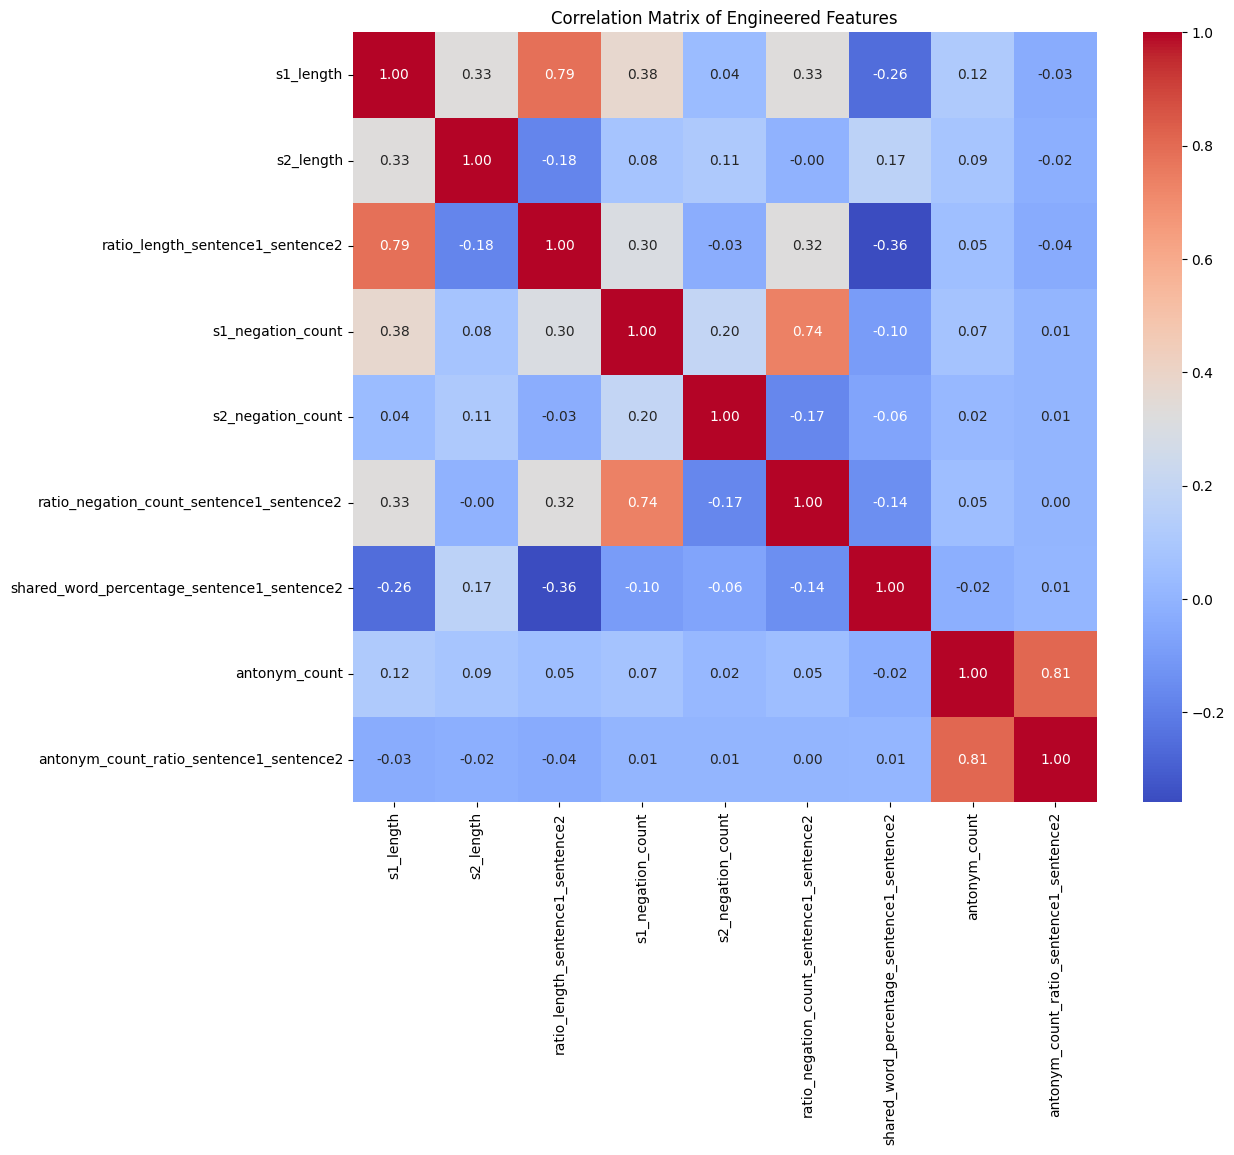

In [13]:
# #correlation matric between the features we calculated

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 10))
correlation_matrix = data_tf_idf[[
    "s1_length",
    "s2_length",
    "ratio_length_sentence1_sentence2",
    "s1_negation_count",
    "s2_negation_count",
    "ratio_negation_count_sentence1_sentence2",
    "shared_word_percentage_sentence1_sentence2",
    "antonym_count",
    "antonym_count_ratio_sentence1_sentence2"
]].corr()

sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap='coolwarm')
plt.title("Correlation Matrix of Engineered Features")
plt.show()

In [14]:
data_tf_idf.drop(columns=['sentence1_cleaned', 'sentence2_cleaned', 'genre'], inplace=True)

**feature importance**

In [15]:
import json
import os

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score


def stepwise_with_base_features(
    X_train_full, X_val_full,
    y_train_enc, y_val_enc,
    base_features, candidate_features,
    model, baseline_score, tol = 10e-3
):
    selected_features = []
    remaining_features = candidate_features.copy()
    best_score = baseline_score

    feature_history = []

    while True:
        changed = False

        # ----- FORWARD STEP -----
        scores_with_candidates = []
        for feature in remaining_features:
            features_to_test = base_features + selected_features + [feature]
            model.fit(X_train_full[features_to_test], y_train_enc)
            y_pred_enc = model.predict(X_val_full[features_to_test])
            score = accuracy_score(y_val_enc, y_pred_enc)

            scores_with_candidates.append((score, feature))
            print(f"testing add {feature:40s} => acc {score:.4f}")

        if scores_with_candidates:
            score, best_feature = max(scores_with_candidates)
            if score > best_score + tol:
                delta_prev = score - best_score
                delta_base = score - baseline_score

                selected_features.append(best_feature)
                remaining_features.remove(best_feature)
                best_score = score
                changed = True

                feature_history.append({
                    "feature": best_feature,
                    "accuracy": score,
                    "delta_vs_previous": delta_prev,
                    "delta_vs_baseline": delta_base
                })

                print(
                    f"ADD    ➜ {best_feature:40s} | "
                    f"acc={score:.4f} | "
                    f"Δprev={delta_prev:+.4f} | "
                    f"Δbase={delta_base:+.4f}"
                )

        # ----- BACKWARD STEP -----
        while selected_features:
            scores_after_removal = []
            for feature in selected_features:
                features_to_test = base_features + [
                    f for f in selected_features if f != feature
                ]
                model.fit(X_train_full[features_to_test], y_train_enc)
                y_pred_enc = model.predict(X_val_full[features_to_test])
                score = accuracy_score(y_val_enc, y_pred_enc)

                scores_after_removal.append((score, feature))
                print(f"testing remove {feature:37s} => acc {score:.4f}")

            score, worst_feature = max(scores_after_removal)

            if score >= best_score - tol:
                selected_features.remove(worst_feature)
                remaining_features.append(worst_feature)
                best_score = score
                changed = True
                print(f"REMOVE ➜ {worst_feature:40s} | acc={best_score:.4f}")
            else:
                break

        if not changed:
            break

    return selected_features, best_score, feature_history

In [16]:
extra_features = [
    "s1_length",
    "s2_length",
    "ratio_length_sentence1_sentence2",
    "s1_negation_count",
    "s2_negation_count",
    "ratio_negation_count_sentence1_sentence2",
    "shared_word_percentage_sentence1_sentence2",
    "antonym_count",
    "antonym_count_ratio_sentence1_sentence2"
]

tfidf_features = [
    c for c in data_tf_idf.columns
    if c not in extra_features + ["gold_label"]
]

y = data_tf_idf["gold_label"]

test_size = 0.2

X_train, X_val, y_train, y_val = train_test_split(
    data_tf_idf.drop(columns=["gold_label"]),
    y,
    test_size=test_size,
    random_state=42
)


In [ ]:
from sklearn.linear_model import LogisticRegression

# Initialize Logistic Regression model
lr_model = LogisticRegression(
    solver='lbfgs',
    max_iter=1000,
    n_jobs=-1,
    random_state=42
)

lr_model.fit(X_train[tfidf_features], y_train)
    
y_val_pred = lr_model.predict(X_val[tfidf_features])
baseline_accuracy = accuracy_score(y_val, y_val_pred)

print(f"baseline accuracy : {baseline_accuracy}")

# Perform stepwise feature selection with Logistic Regression
selected_features_lr, final_accuracy_lr, feature_history_lr = stepwise_with_base_features(
    X_train_full=X_train,
    X_val_full=X_val,
    y_train_enc=y_train,
    y_val_enc=y_val,
    base_features=tfidf_features,
    candidate_features=extra_features,
    model=lr_model,
    baseline_score=baseline_accuracy,
    tol= (4 / (NUM_DATA_POINTS * test_size))
)

# Save Logistic Regression results
results_lr = {
    "baseline_accuracy_tfidf": baseline_accuracy,
    "final_accuracy": final_accuracy_lr,
    "selected_features": selected_features_lr,
    "feature_contributions": feature_history_lr
}

OUTPUT_PATH_LR = f"../features_importance/{NUM_EXP}_logistic_regression_feature_engineering_importance_results.json"
os.makedirs(os.path.dirname(OUTPUT_PATH_LR), exist_ok=True)

with open(OUTPUT_PATH_LR, "w") as f:
    json.dump(results_lr, f, indent=2)

print("\n=== Logistic Regression Results ===")
print("\nFinal selected extra features:")
for f in selected_features_lr:
    print("-", f)

print(f"\nFinal validation accuracy (with TF-IDF + extras): {final_accuracy_lr:.4f}")
print(f"\nResults written to {OUTPUT_PATH_LR}")

In [18]:
from sklearn.preprocessing import LabelEncoder
import xgboost as xgb

label_encoder = LabelEncoder()
y_train_enc = label_encoder.fit_transform(y_train)
y_val_enc = label_encoder.transform(y_val)

xgb_model = xgb.XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    n_jobs=-1,
    random_state=42,
    eval_metric="mlogloss"
)

xgb_model.fit(X_train[tfidf_features], y_train_enc)

y_val_pred_enc = xgb_model.predict(X_val[tfidf_features])
baseline_accuracy = accuracy_score(y_val_enc, y_val_pred_enc)

print(f"Baseline TF-IDF validation accuracy: {baseline_accuracy:.4f}")

selected_features, final_accuracy, feature_history = stepwise_with_base_features(
    X_train_full=X_train,
    X_val_full=X_val,
    y_train_enc=y_train_enc,
    y_val_enc=y_val_enc,
    base_features=tfidf_features,
    candidate_features=extra_features,
    model=xgb_model,
    baseline_score=baseline_accuracy,
    tol= (4 / (NUM_DATA_POINTS * test_size))
)


results = {
    "baseline_accuracy_tfidf": baseline_accuracy,
    "final_accuracy": final_accuracy,
    "selected_features": selected_features,
    "feature_contributions": feature_history
}

OUTPUT_PATH = f"../features_importance/{NUM_EXP}_feature_engineering_importance_results.json"
os.makedirs(os.path.dirname(OUTPUT_PATH), exist_ok=True)

with open(OUTPUT_PATH, "w") as f:
    json.dump(results, f, indent=2)


print("\nFinal selected extra features:")
for f in selected_features:
    print("-", f)

print(f"\nFinal validation accuracy (with TF-IDF + extras): {final_accuracy:.4f}")
print(f"\nResults written to {OUTPUT_PATH}")

Baseline TF-IDF validation accuracy: 0.4975
testing add s1_length                                => acc 0.4950
testing add s2_length                                => acc 0.4900
testing add ratio_length_sentence1_sentence2         => acc 0.5120
testing add s1_negation_count                        => acc 0.4940
testing add s2_negation_count                        => acc 0.5100
testing add ratio_negation_count_sentence1_sentence2 => acc 0.5120
testing add shared_word_percentage_sentence1_sentence2 => acc 0.5430
testing add antonym_count                            => acc 0.4965
testing add antonym_count_ratio_sentence1_sentence2  => acc 0.4995
ADD    ➜ shared_word_percentage_sentence1_sentence2 | acc=0.5430 | Δprev=+0.0455 | Δbase=+0.0455
testing remove shared_word_percentage_sentence1_sentence2 => acc 0.4975
testing add s1_length                                => acc 0.5470
testing add s2_length                                => acc 0.5490
testing add ratio_length_sentence1_sentence2    

In [ ]:
from sklearn.naive_bayes import MultinomialNB

# Initialize Naive Bayes model
nb_model = MultinomialNB()

nb_model.fit(X_train[tfidf_features], y_train)
    
y_val_pred_nb = nb_model.predict(X_val[tfidf_features])
baseline_accuracy_nb = accuracy_score(y_val, y_val_pred_nb)

print(f"baseline accuracy (Naive Bayes): {baseline_accuracy_nb}")

# Perform stepwise feature selection with Naive Bayes
selected_features_nb, final_accuracy_nb, feature_history_nb = stepwise_with_base_features(
    X_train_full=X_train,
    X_val_full=X_val,
    y_train_enc=y_train,
    y_val_enc=y_val,
    base_features=tfidf_features,
    candidate_features=extra_features,
    model=nb_model,
    baseline_score=baseline_accuracy_nb,
    tol= (4 / (NUM_DATA_POINTS * test_size))
)

# Save Naive Bayes results
results_nb = {
    "baseline_accuracy_tfidf": baseline_accuracy_nb,
    "final_accuracy": final_accuracy_nb,
    "selected_features": selected_features_nb,
    "feature_contributions": feature_history_nb
}

OUTPUT_PATH_NB = f"../features_importance/{NUM_EXP}_naive_bayes_feature_engineering_importance_results.json"
os.makedirs(os.path.dirname(OUTPUT_PATH_NB), exist_ok=True)

with open(OUTPUT_PATH_NB, "w") as f:
    json.dump(results_nb, f, indent=2)

print("\n=== Naive Bayes Results ===")
print("\nFinal selected extra features:")
for f in selected_features_nb:
    print("-", f)

print(f"\nFinal validation accuracy (with TF-IDF + extras): {final_accuracy_nb:.4f}")
print(f"\nResults written to {OUTPUT_PATH_NB}")